# Medical Device Failure & Healthcare Financial Risk BI Project

## Notebook 04: Exploratory Data Analysis

This notebook explores the cleaned medical device failure and financial datasets. <br>
 The goal is to identify patterns in device failure events, maintenance cost, downtime, manufacturer performance, operational risk, replacement review flags, and healthcare expense categories.

In [2]:

# ==========================================
# Notebook 04: Exploratory Data Analysis
# Medical Device Failure & Healthcare Financial Risk BI Project
# ==========================================


import pandas as pd 
import numpy as np
from pathlib import Path  
import matplotlib.pyplot as plt


pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)   


PROJECT_ROOT = Path(r"C:\Users\Charl\OneDrive\Documents\GitHub\Medical Device Failure & Healthcare Supply Chain Risk BI Project")

raw_data_path = Path(
    r"C:\Users\Charl\OneDrive\Documents\GitHub\Medical Device Failure & Healthcare Supply Chain Risk BI Project\data\raw"
)

raw_files = [
    raw_data_path / "financial_data.csv",
    raw_data_path / "Medical_Device_Failure_dataset.csv"
]
raw_files 


cleaned_data_path =Path(r"C:\Users\Charl\OneDrive\Documents\GitHub\Medical Device Failure & Healthcare Supply Chain Risk BI Project\data\cleaned")

cleaned_files = [
    cleaned_data_path / "financial_data_cleaned.csv",
    cleaned_data_path / "medical_device_failure_cleaned.csv"
]
cleaned_files


exports_path =Path(r"C:\Users\Charl\OneDrive\Documents\GitHub\Medical Device Failure & Healthcare Supply Chain Risk BI Project\data\exports")

print("Libraries imported and paths set successfully")

Libraries imported and paths set successfully


In [3]:
# ==========================================
# Load raw and cleaned datasets
# ==========================================

device_raw = pd.read_csv(raw_data_path/"Medical_Device_Failure_dataset.csv")
financial_raw = pd.read_csv( raw_data_path/"financial_data.csv")

device_clean = pd.read_csv(cleaned_data_path/"medical_device_failure_cleaned.csv")
financial_clean  =pd.read_csv(cleaned_data_path/"financial_data_cleaned.csv")

print("\nDevice raw shape:", device_raw.shape)
print("Device cleaned shape:", device_clean.shape)

print("\nFinancial raw shape:", financial_raw.shape)
print("Financial cleaned shape:", financial_clean.shape)


Device raw shape: (4149, 13)
Device cleaned shape: (4149, 28)

Financial raw shape: (500, 4)
Financial cleaned shape: (500, 10)


In [4]:
# ==========================================
# EDA KPI summary
# ==========================================

eda_kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Devices",
        "Total Failure Events",
        "Devices with Failure Reported",
        "Average Downtime Hours",
        "Total Maintenance Cost",
        "Average Maintenance Cost",
        "High Risk Devices",
        "Devices for Replacement Review",
        "Total Financial Expenses",
        "Average Financial Expense"
    ],
    "Value": [
        device_clean["device_id"].nunique(),
        device_clean["failure_event_count"].sum(),
        device_clean["failure_flag"].sum(),
        round(device_clean["downtime_hours"].mean(), 2),
        round(device_clean["maintenance_cost"].sum(), 2),
        round(device_clean["maintenance_cost"].mean(), 2),
        (device_clean["operational_risk_level"] == "High").sum(),
        (device_clean["replacement_review_flag"] == "Review for Replacement").sum(),
        round(financial_clean["amount"].sum(), 2),
        round(financial_clean["amount"].mean(), 2)
    ]
})

eda_kpi_summary

,KPI,Value
0,Total Devices,4149.00
1,Total Failure Events,8123.00
2,Devices with Failure Reported,3561.00
3,Average Downtime Hours,10.62
4,Total Maintenance Cost,36146261.54
5,Average Maintenance Cost,8712.04
6,High Risk Devices,357.00
7,Devices for Replacement Review,1054.00
8,Total Financial Expenses,12360245.73
9,Average Financial Expense,24720.49


In [5]:
eda_kpi_summary.to_csv(exports_path/"eda_kpi_summary.csv", index=False)
print("EDA KPI summary reported.")

EDA KPI summary reported.


In [6]:
# ==========================================
# Device type summary
# ==========================================

eda_device_type_summary = device_clean.groupby("device_type").agg(
    device_count=("device_id", "count"),
    total_failure_events=("failure_event_count", "sum"),
    avg_failure_events=("failure_event_count", "mean"),
    total_maintenance_cost=("maintenance_cost", "sum"),
    avg_maintenance_cost=("maintenance_cost", "mean"),
    avg_downtime_hours=("downtime_hours", "mean"),
    high_risk_devices=("operational_risk_level", lambda x: (x == "High").sum()),
    replacement_review_count=("replacement_review_flag", lambda x: (x == "Review for Replacement").sum())
).reset_index()

eda_device_type_summary = eda_device_type_summary.sort_values(
    by="total_failure_events",
    ascending=False
)

eda_device_type_summary

,device_type,device_count,total_failure_events,avg_failure_events,total_maintenance_cost,avg_maintenance_cost,avg_downtime_hours,high_risk_devices,replacement_review_count
1,Defibrillator,701,1424,2.031384,6.181605e+06,8818.266143,10.661740,75,194
2,Infusion Pump,705,1413,2.004255,5.988242e+06,8493.960380,10.616099,46,158
5,X-Ray Machine,729,1413,1.938272,6.297547e+06,8638.610313,10.601962,64,200
4,PET Scanner,679,1310,1.929308,6.005311e+06,8844.346062,11.038969,59,176
3,MRI Scanner,673,1296,1.925706,5.781104e+06,8590.050333,10.463373,54,167
0,CT Scanner,662,1267,1.913897,5.892453e+06,8900.986615,10.337795,59,159


In [7]:
eda_device_type_summary.to_csv(exports_path/"eda_device_type_summary.csv", index=False)
print("Device type summary exported.")

Device type summary exported.


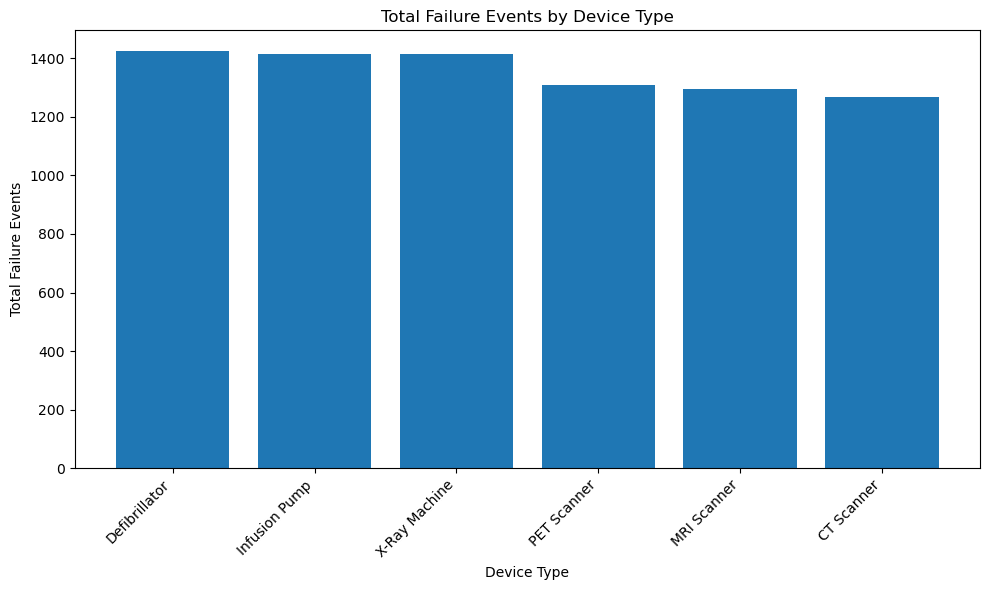

In [8]:
# ==========================================
# Chart: Total failure events by device type
# ==========================================


top_device_failures =eda_device_type_summary.sort_values(
    by="total_failure_events",
    ascending=False  
)


plt.figure(figsize=(10,6))
plt.bar(top_device_failures["device_type"], top_device_failures["total_failure_events"])
plt.title("Total Failure Events by Device Type")
plt.xlabel("Device Type")
plt.ylabel("Total Failure Events")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [9]:
# ==========================================
# Manufacturer summary
# ==========================================

eda_manufacturer_summary = device_clean.groupby("manufacturer").agg(
    device_count=("device_id", "count"),
    total_failure_events=("failure_event_count", "sum"),
    avg_failure_events=("failure_event_count", "mean"),
    total_maintenance_cost=("maintenance_cost", "sum"),
    avg_maintenance_cost=("maintenance_cost", "mean"),
    avg_downtime_hours=("downtime_hours", "mean"),
    high_risk_devices=("operational_risk_level", lambda x: (x == "High").sum())
).reset_index()

eda_manufacturer_summary = eda_manufacturer_summary.sort_values(
    by="total_maintenance_cost",
    ascending=False
)

eda_manufacturer_summary

,manufacturer,device_count,total_failure_events,avg_failure_events,total_maintenance_cost,avg_maintenance_cost,avg_downtime_hours,high_risk_devices
4,ScanPro,729,1389,1.905350,6.326665e+06,8678.553327,10.489753,62
1,ImagingTech,698,1380,1.977077,6.107918e+06,8750.598272,10.690860,62
3,RescueTech,689,1349,1.957910,6.027266e+06,8747.845598,10.649608,58
5,UltraMed,665,1344,2.021053,5.982444e+06,8996.156182,10.571594,55
0,CardioSync,677,1274,1.881832,5.860667e+06,8656.820093,10.696662,55
2,MedEquip,691,1387,2.007236,5.841302e+06,8453.403606,10.635904,65


In [10]:
eda_manufacturer_summary.to_csv(exports_path/"eda_manufacturer_summary.csv",index=False)
print("Manufacturer summary exported.")

Manufacturer summary exported.


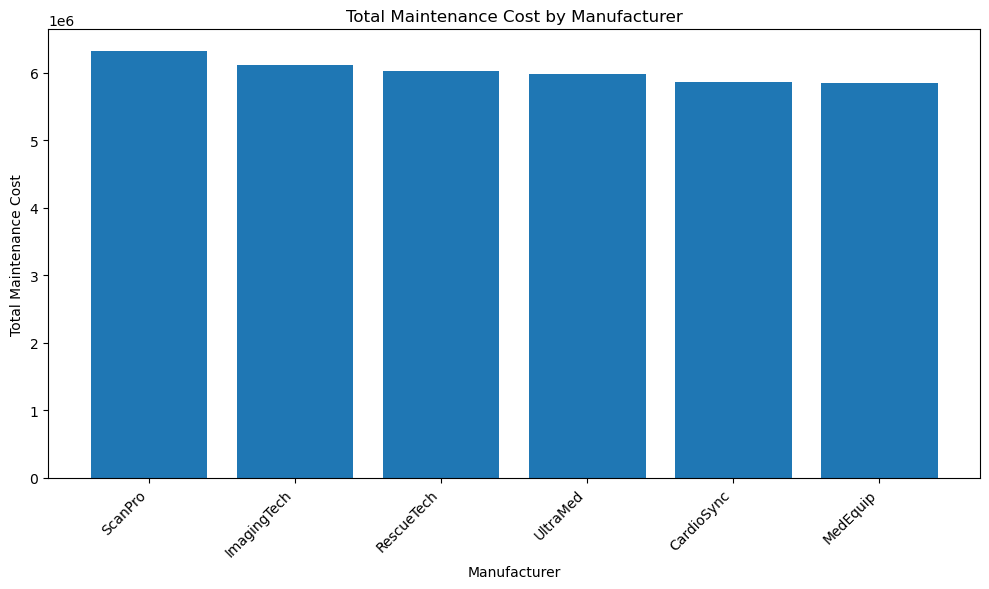

In [11]:
# ==========================================
# Chart: Total maintenance cost by manufacturer
# ==========================================

manufacturer_cost = eda_manufacturer_summary.sort_values(
    by="total_maintenance_cost",
    ascending=False             
)

plt.figure(figsize=(10,6))
plt.bar(manufacturer_cost["manufacturer"],manufacturer_cost["total_maintenance_cost"])
plt.title("Total Maintenance Cost by Manufacturer")
plt.xlabel("Manufacturer")
plt.ylabel("Total Maintenance Cost")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()











In [12]:
# ==========================================
# Failure type summary
# ==========================================

eda_failure_type_summary = device_clean.groupby("failure_type").agg(
    record_count=("device_id", "count"),
    total_failure_events=("failure_event_count", "sum"),
    avg_maintenance_cost=("maintenance_cost", "mean"),
    avg_downtime_hours=("downtime_hours", "mean")
).reset_index()

eda_failure_type_summary = eda_failure_type_summary.sort_values(
    by="record_count",
    ascending=False
)

eda_failure_type_summary

,failure_type,record_count,total_failure_events,avg_maintenance_cost,avg_downtime_hours
1,Electerical Issue,1022,1987,8820.576098,10.574736
6,Software/Data Issue,861,1719,7760.353035,9.851057
5,Sensor Issue,738,1451,9835.527798,11.956856
0,Battery Issue,513,935,8912.934685,10.795458
4,Overheating,488,958,8973.184652,10.396434
3,Mechanical Issue,276,579,8244.849293,10.146232
2,General Maintenance,251,494,7826.778019,10.130677


In [13]:
eda_failure_type_summary.to_csv(exports_path/"eda_failure_type_summary.csv", index=False)
print("Failure type summary exported.")

Failure type summary exported.


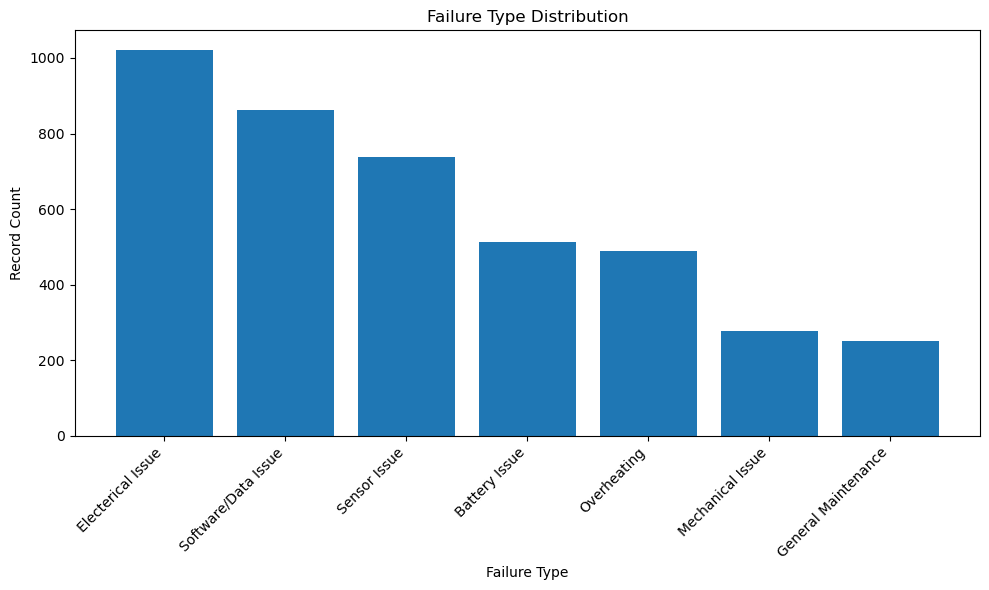

In [14]:
# ==========================================
# Chart: Failure type distribution
# ==========================================

plt.figure(figsize=(10, 6))
plt.bar(eda_failure_type_summary["failure_type"], eda_failure_type_summary["record_count"])
plt.title("Failure Type Distribution")
plt.xlabel("Failure Type")
plt.ylabel("Record Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [15]:
# ==========================================
# Operational risk summary
# ==========================================

eda_risk_summary = device_clean.groupby("operational_risk_level").agg(
    device_count=("device_id", "count"),
    total_failure_events=("failure_event_count", "sum"),
    total_maintenance_cost=("maintenance_cost", "sum"),
    avg_maintenance_cost=("maintenance_cost", "mean"),
    avg_downtime_hours=("downtime_hours", "mean")
).reset_index()

risk_order = ["Low", "Medium", "High"]
eda_risk_summary["risk_sort"] = eda_risk_summary["operational_risk_level"].map({
    "Low": 1,
    "Medium": 2,
    "High": 3
})

eda_risk_summary = eda_risk_summary.sort_values("risk_sort").drop(columns="risk_sort")

eda_risk_summary

,operational_risk_level,device_count,total_failure_events,total_maintenance_cost,avg_maintenance_cost,avg_downtime_hours
1,Low,2292,3727,1.366286e+07,5961.106159,7.229202
2,Medium,1500,3378,1.644999e+07,10966.658269,13.422500
0,High,357,1018,6.033419e+06,16900.332835,20.630000


In [16]:
eda_risk_summary.to_csv(exports_path/"eda_risk_summary.csv", index=False)
print("Risk summary exported.")

Risk summary exported.


In [17]:
# ==========================================
# Financial expense category summary
# ==========================================

eda_financial_category_summary = financial_clean.groupby("corrected_expense_category").agg(
    expense_count=("amount","count"),
    total_amount=("amount","sum"),
    average_amount=("amount","mean"),
    min_amount=("amount","min"),
    max_amount=("amount","max")
).reset_index()

eda_financial_category_summary=eda_financial_category_summary.sort_values(
    by="total_amount",
    ascending=False
)

eda_financial_category_summary



,corrected_expense_category,expense_count,total_amount,average_amount,min_amount,max_amount
1,Staffing,183,4376609.49,23915.898852,1133.11,49581.16
2,Supplies,172,4264251.13,24792.157733,1110.27,49511.97
0,Equipment,145,3719385.11,25650.931793,3242.27,49266.87


In [18]:
eda_financial_category_summary.to_csv(exports_path/"eda_financial_category_summary.csv", index=False)

print("Financial category summary exported.")

Financial category summary exported.


In [19]:
# ==========================================
# Replacement review summary
# ==========================================

eda_replacement_summary = device_clean.groupby("replacement_review_flag").agg(
    device_count=("device_id", "count"),
    total_failure_events=("failure_event_count", "sum"),
    total_maintenance_cost=("maintenance_cost", "sum"),
    avg_maintenance_cost=("maintenance_cost", "mean"),
    avg_downtime_hours=("downtime_hours", "mean")
).reset_index()

eda_replacement_summary

,replacement_review_flag,device_count,total_failure_events,total_maintenance_cost,avg_maintenance_cost,avg_downtime_hours
0,Monitor,3095,5060,2.259948e+07,7301.933137,8.889561
1,Review for Replacement,1054,3063,1.354678e+07,12852.731008,15.706641


In [20]:
# ==========================================
# Export replacement review summary
# ==========================================

eda_replacement_summary.to_csv(exports_path / "eda_replacement_summary.csv", index=False)

print("Replacement summary exported.")

Replacement summary exported.


In [23]:
kpi_definition_table = pd.DataFrame({
    "KPI_Name": [
        "Total Devices",
        "Total Failure Events",
        "Devices with Failure Reported",
        "Average Downtime Hours",
        "Total Maintenance Cost",
        "Average Maintenance Cost",
        "High-Risk Devices",
        "Devices for Replacement Review",
        "Total Financial Expenses",
        "Top Expense Category"
    ],
    "Category": [
        "Operational",
        "Operational",
        "Operational",
        "Operational",
        "Financial",
        "Financial",
        "Risk",
        "Risk",
        "Financial",
        "Financial"
    ],
    "Formula": [
        "Count distinct device_id",
        "Sum of failure_event_count",
        "Sum of failure_flag",
        "Average of downtime_hours",
        "Sum of maintenance_cost",
        "Average of maintenance_cost",
        "Count where operational_risk_level = High",
        "Count where replacement_review_flag = Review for Replacement",
        "Sum of amount",
        "Corrected expense category with highest total amount"
    ],
    "Business_Meaning": [
        "Shows the total number of medical devices included in the analysis",
        "Shows the total recorded device failure burden",
        "Shows how many devices had at least one reported failure",
        "Shows the average amount of time devices were unavailable",
        "Shows the total cost burden of device maintenance",
        "Shows the typical maintenance cost per device record",
        "Shows how many devices meet high operational risk criteria",
        "Shows how many devices may need replacement evaluation",
        "Shows total healthcare expenses from the financial support dataset",
        "Shows the largest spending category after category correction"
    ],
    "Primary_Stakeholder": [
        "Operations / Biomedical Engineering",
        "Operations / Biomedical Engineering",
        "Operations / Risk",
        "Operations / Department Leadership",
        "Finance / Operations",
        "Finance / Biomedical Engineering",
        "Risk / Operations",
        "Operations / Finance",
        "Finance",
        "Finance / Leadership"
    ]
})

kpi_definition_table.to_csv(exports_path / "kpi_definition_table.csv", index=False)

print("KPI definition table exported successfully.")
print(exports_path / "kpi_definition_table.csv")

kpi_definition_table

KPI definition table exported successfully.
C:\Users\Charl\OneDrive\Documents\GitHub\Medical Device Failure & Healthcare Supply Chain Risk BI Project\data\exports\kpi_definition_table.csv


,KPI_Name,Category,Formula,Business_Meaning,Primary_Stakeholder
0,Total Devices,Operational,Count distinct device_id,Shows the total number of medical devices incl...,Operations / Biomedical Engineering
1,Total Failure Events,Operational,Sum of failure_event_count,Shows the total recorded device failure burden,Operations / Biomedical Engineering
2,Devices with Failure Reported,Operational,Sum of failure_flag,Shows how many devices had at least one report...,Operations / Risk
3,Average Downtime Hours,Operational,Average of downtime_hours,Shows the average amount of time devices were ...,Operations / Department Leadership
4,Total Maintenance Cost,Financial,Sum of maintenance_cost,Shows the total cost burden of device maintenance,Finance / Operations
5,Average Maintenance Cost,Financial,Average of maintenance_cost,Shows the typical maintenance cost per device ...,Finance / Biomedical Engineering
6,High-Risk Devices,Risk,Count where operational_risk_level = High,Shows how many devices meet high operational r...,Risk / Operations
7,Devices for Replacement Review,Risk,Count where replacement_review_flag = Review f...,Shows how many devices may need replacement ev...,Operations / Finance
8,Total Financial Expenses,Financial,Sum of amount,Shows total healthcare expenses from the finan...,Finance
9,Top Expense Category,Financial,Corrected expense category with highest total ...,Shows the largest spending category after cate...,Finance / Leadership


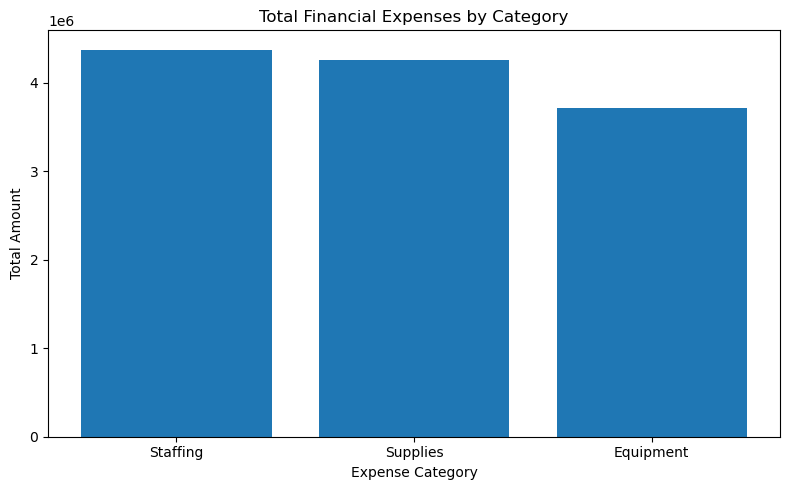

In [19]:
# ==========================================
# Chart: Total financial expenses by corrected category
# ==========================================

plt.figure(figsize=(8,5))
plt.bar(
    eda_financial_category_summary["corrected_expense_category"],
    eda_financial_category_summary["total_amount"]
)
plt.title("Total Financial Expenses by Category")
plt.xlabel("Expense Category")
plt.ylabel("Total Amount")
plt.tight_layout()
plt.show()

In [20]:
# ==========================================
# Monthly financial expense trend
# ==========================================

financial_monthly_summary = financial_clean.groupby("expense_month_year").agg(
    total_amount=("amount", "sum"),
    expense_count=("amount", "count")
).reset_index()

financial_monthly_summary = financial_monthly_summary.sort_values("expense_month_year")

financial_monthly_summary

,expense_month_year,total_amount,expense_count
0,2024-10,767387.24,31
1,2024-11,665495.80,30
2,2024-12,777622.79,31
3,2025-01,798419.76,31
4,2025-02,696601.88,28
5,2025-03,699112.80,31
6,2025-04,817803.51,30
7,2025-05,784615.56,31
8,2025-06,713146.07,30
9,2025-07,759202.24,31


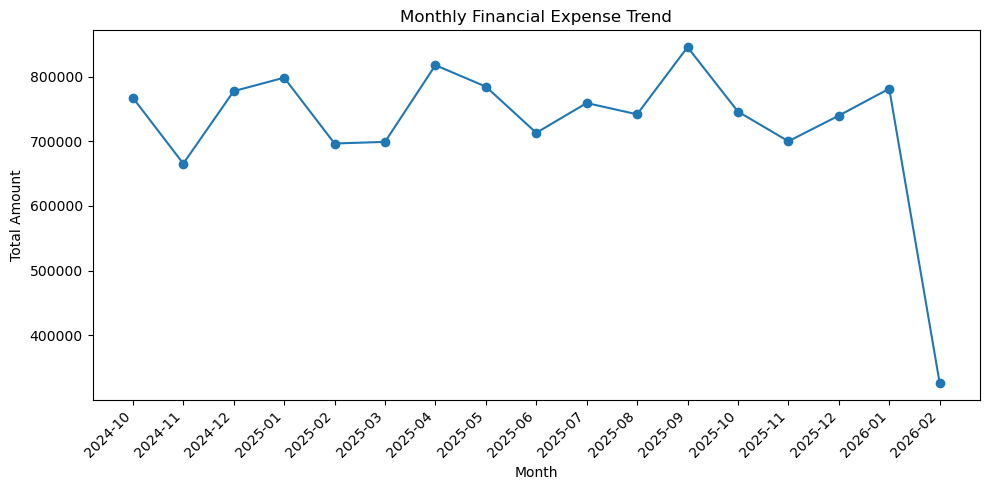

In [23]:
# ==========================================
# Chart: Monthly financial expense trend
# ==========================================

plt.figure(figsize=(10, 5))
plt.plot(financial_monthly_summary["expense_month_year"], financial_monthly_summary["total_amount"], marker="o")
plt.title("Monthly Financial Expense Trend")
plt.xlabel("Month")
plt.ylabel("Total Amount")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()



In [24]:
# ==========================================
# Starter EDA findings
# ==========================================

top_device_type = eda_device_type_summary.iloc[0]["device_type"]
top_failure_events = eda_device_type_summary.iloc[0]["total_failure_events"]

top_manufacturer = eda_manufacturer_summary.iloc[0]["manufacturer"]
top_manufacturer_cost = eda_manufacturer_summary.iloc[0]["total_maintenance_cost"]

top_failure_type = eda_failure_type_summary.iloc[0]["failure_type"]
top_financial_category = eda_financial_category_summary.iloc[0]["corrected_expense_category"]

print("Starter EDA Findings")
print("--------------------")
print(f"Device type with highest total failure events: {top_device_type} ({top_failure_events} events)")
print(f"Manufacturer with highest total maintenance cost: {top_manufacturer} (${top_manufacturer_cost:,.2f})")
print(f"Most common failure type: {top_failure_type}")
print(f"Highest financial expense category: {top_financial_category}")

Starter EDA Findings
--------------------
Device type with highest total failure events: Defibrillator (1424 events)
Manufacturer with highest total maintenance cost: ScanPro ($6,326,665.38)
Most common failure type: Electerical Issue
Highest financial expense category: Staffing


## EDA Summary

Exploratory data analysis was completed on the cleaned medical device failure and financial datasets.

The analysis reviewed device failure events, maintenance cost, downtime hours, device type patterns, manufacturer-level maintenance burden, <br>

failure type categories, operational risk levels, replacement review flags, and healthcare financial expense categories.

The EDA outputs will support later SQL queries, Excel validation tables, Power BI dashboard visuals, and PowerPoint executive summary findings.